# Імпортуємо бібліотеки та завантажуємо датасет

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import cross_val_score
import logging
import lightgbm as lgb

Завантажуємо датасет та робимо попередній огляд

In [2]:
df = pd.read_csv('/kaggle/input/credit-risk-customers/credit_customers.csv')
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


Перевіряємо на порожні значення та дублікати

In [3]:
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [4]:
df.duplicated().sum()

0

# Підготовлюємо данні до роботи

Переглядаємо типи даних

In [5]:
df.dtypes

checking_status            object
duration                  float64
credit_history             object
purpose                    object
credit_amount             float64
savings_status             object
employment                 object
installment_commitment    float64
personal_status            object
other_parties              object
residence_since           float64
property_magnitude         object
age                       float64
other_payment_plans        object
housing                    object
existing_credits          float64
job                        object
num_dependents            float64
own_telephone              object
foreign_worker             object
class                      object
dtype: object

Обираємо категоріальні ознаки

In [6]:
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')

Перевіряємо які в них є унікальні значення

In [7]:
df['class'].unique()

array(['good', 'bad'], dtype=object)

## Закодовуємо категоріальні ознаки за допомогою Label Encoding

In [8]:
to_encode = ['checking_status', 'credit_history','purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker', 'class']

for col in to_encode:
    df[col] = LabelEncoder().fit_transform(df[col])

In [9]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,6.0,1,6,1169.0,4,3,4.0,3,2,...,3,67.0,1,1,2.0,1,1.0,1,1,1
1,0,48.0,3,6,5951.0,2,0,2.0,0,2,...,3,22.0,1,1,1.0,1,1.0,0,1,0
2,3,12.0,1,2,2096.0,2,1,2.0,3,2,...,3,49.0,1,1,1.0,3,2.0,0,1,1
3,1,42.0,3,3,7882.0,2,1,2.0,3,1,...,1,45.0,1,0,1.0,1,2.0,0,1,1
4,1,24.0,2,4,4870.0,2,0,3.0,3,2,...,2,53.0,1,0,2.0,1,2.0,0,1,0


# EDA

Оглядаємо розмір, опис, та типи даних

In [10]:
df.shape

(1000, 21)

In [11]:
df.describe()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.582000,20.903000,2.219000,4.484000,3271.258000,2.1450,1.525000,2.973000,1.878000,1.866000,...,1.386000,35.546000,0.908000,1.071000,1.407000,1.274000,1.155000,0.404000,0.963000,0.700000
std,1.253334,12.058814,1.064035,2.421075,2822.736876,1.1114,1.344315,1.118715,1.350904,0.445244,...,1.210979,11.375469,0.421561,0.531264,0.577654,0.946478,0.362086,0.490943,0.188856,0.458487
min,0.000000,4.000000,0.000000,0.000000,250.000000,0.0000,0.000000,1.000000,0.000000,0.000000,...,0.000000,19.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,12.000000,1.000000,3.000000,1365.500000,2.0000,0.000000,2.000000,0.000000,2.000000,...,0.000000,27.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.000000,18.000000,3.000000,4.000000,2319.500000,2.0000,1.000000,3.000000,3.000000,2.000000,...,1.000000,33.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,3.000000,24.000000,3.000000,6.000000,3972.250000,2.0000,3.000000,4.000000,3.000000,2.000000,...,3.000000,42.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,3.000000,72.000000,4.000000,9.000000,18424.000000,4.0000,4.000000,4.000000,3.000000,2.000000,...,3.000000,75.000000,2.000000,2.000000,4.000000,3.000000,2.000000,1.000000,1.000000,1.000000


In [12]:
df.dtypes

checking_status             int64
duration                  float64
credit_history              int64
purpose                     int64
credit_amount             float64
savings_status              int64
employment                  int64
installment_commitment    float64
personal_status             int64
other_parties               int64
residence_since           float64
property_magnitude          int64
age                       float64
other_payment_plans         int64
housing                     int64
existing_credits          float64
job                         int64
num_dependents            float64
own_telephone               int64
foreign_worker              int64
class                       int64
dtype: object

**Призначаємо таргетом "credit_amount"**

Будуємо графік кореляції

<Axes: >

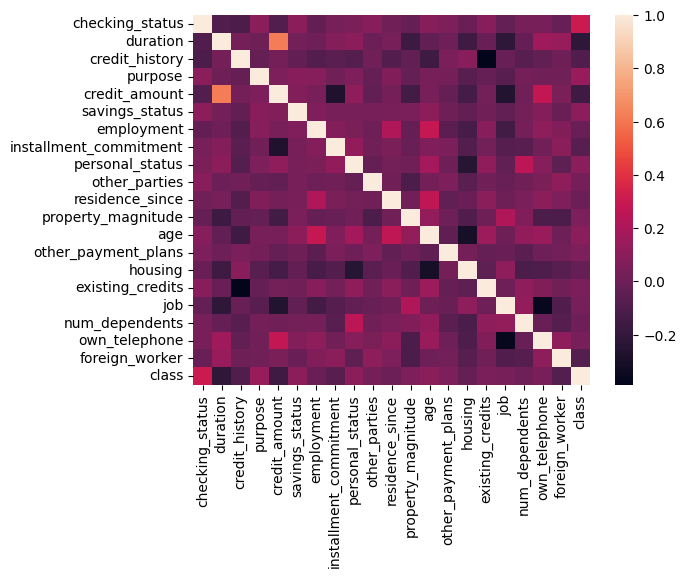

In [13]:
sns.heatmap(df.corr())

За данною кореляційною матрицею, можна зробити висновок, що даних які сильно корелюють між собою немає.

Будуємо графік відношення таргету з іншими ознаками

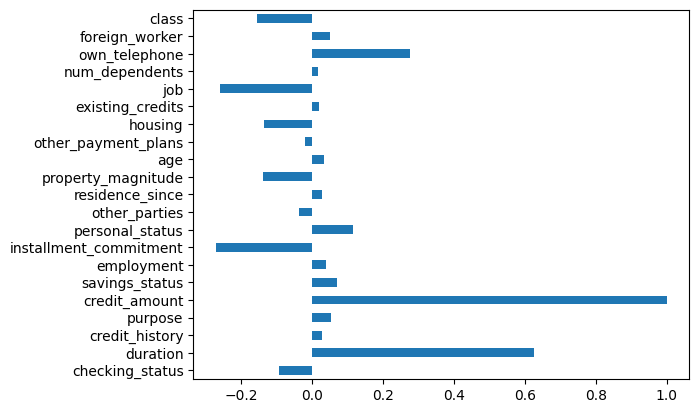

In [14]:
ax = df.corrwith(df["credit_amount"]).plot(kind="barh")

На таргет розмір кредиту, найбільший вплив мають: тривалість, розстрочка у відсотках від наявного доходу, робота, наявність телефону, клас та розмір власності.

Розділяємо датасет на тестовий та тренувальний

In [15]:
X = df.loc[:, ~df.columns.isin(['credit_amount'])]
y = df['credit_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(f"Train size – {X_train.shape}")
print(f"Test size – {y_train.shape}")

Train size – (800, 20)
Test size – (800,)


# Bosting XGBOOST

Будуємо DMatrix для оптимізації швидкості та пам'яті

In [16]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test)

Встановлюємо параметри для навчання моделі

In [17]:
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.1,
    'max_depth': 3,
    'seed': 42
}
num_rounds = 100
xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.1, eval_metric='rmse',
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Прогнозування на тестовому наборі

In [18]:
predictions = xgb_model.predict(X_test)

Оцінка моделі XGBoost

In [19]:
rmse = mean_squared_error(y_test, predictions, squared=False)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("оцінка моделі XGBoost ")
print(f"r2 score: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

оцінка моделі XGBoost 
r2 score: 0.6405435375388017
MAE: 1119.3689324951172
RMSE: 1668.8848703410026


Оцінюємо важливість ознак

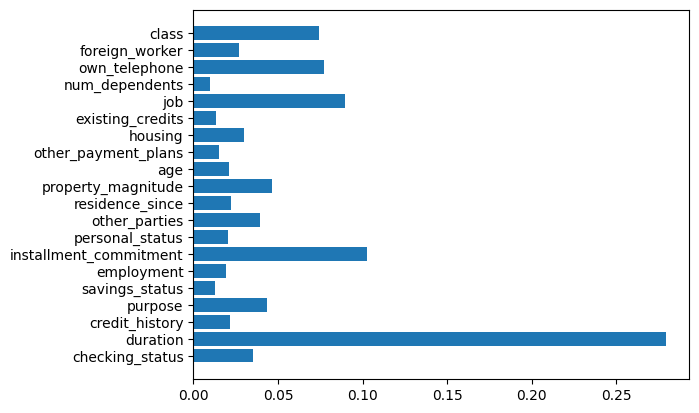

In [20]:
importance = xgb_model.feature_importances_
plt.barh(X_train.columns, importance)
plt.show()

# LightGBM

In [21]:
params_lgb = {
    'objective': 'regression',  # Задача регресії
    'metric': 'l2',  # Метрика середньоквадратичної помилки
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}
lgb_model = lgb.LGBMRegressor(**params_lgb)
lgb_model.fit(X_train, y_train)

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
              learning_rate=0.05, metric='l2', objective='regression',
              verbose=-1)

In [22]:
lpredict = lgb_model.predict(X_test)

In [23]:
rmse = mean_squared_error(y_test, lpredict, squared=False)
mae = mean_absolute_error(y_test, lpredict)
r2 = r2_score(y_test, lpredict)
print("оцінка моделі LightGBM ")
print(f"r2 score: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

оцінка моделі LightGBM 
r2 score: 0.6181222095864478
MAE: 1160.5102504982035
RMSE: 1720.1464758702894


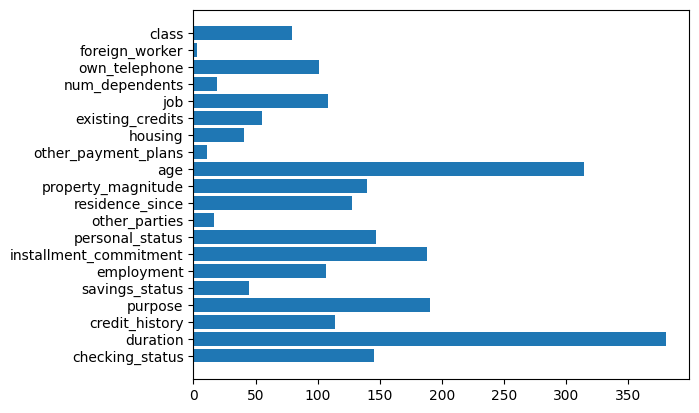

In [24]:
importance = lgb_model.feature_importances_
plt.barh(X_train.columns, importance)
plt.show()

# Валідація моделі¶


Проводимо крос-валідацію

In [25]:
# XGBOOST
print("result for XGBOOST")
mae_scores = -cross_val_score(xgb_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print("Mean MAE :", np.mean(mae_scores))
rmse_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print("Mean RMSE:", np.mean(-rmse_scores))
r2_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print("Mean R2 score:", np.mean(r2_scores))

#LightGBM
print("result for LightGBM")
mae_scores = -cross_val_score(lgb_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print("Mean MAE :", np.mean(mae_scores))
rmse_scores = cross_val_score(lgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print("Mean RMSE:", np.mean(-rmse_scores))
r2_scores = cross_val_score(lgb_model, X, y, cv=5, scoring='r2')
print("Mean R2 score:", np.mean(r2_scores))

result for XGBOOST
Mean MAE : 1212.7856596717834
Mean RMSE: 1816.357068677741
Mean R2 score: 0.5734442961514536
result for LightGBM
Mean MAE : 1220.8197606159786
Mean RMSE: 1833.3917616719511
Mean R2 score: 0.5663299643383819


Оцінка моделі

In [26]:
print(f"Model score is – {xgb_model.score(X_test, y_test)}")
print(f"Model score is – {lgb_model.score(X_test, y_test)}")

Model score is – 0.6405435375388017
Model score is – 0.6181222095864478
